Saving PriceHistory__5_.xlsx (2) (1).csv to PriceHistory__5_.xlsx (2) (1).csv


/tmp/ipykernel_8264/3527899357.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


Cleaned Data Shape: (1259, 2)
1       Date   Close
0 2019-12-31  229.93
1 2020-01-02  234.32
2 2020-01-03  231.58
3 2020-01-06  233.95
4 2020-01-07  235.49
Train size: (1249, 2)
Test size: (10, 2)


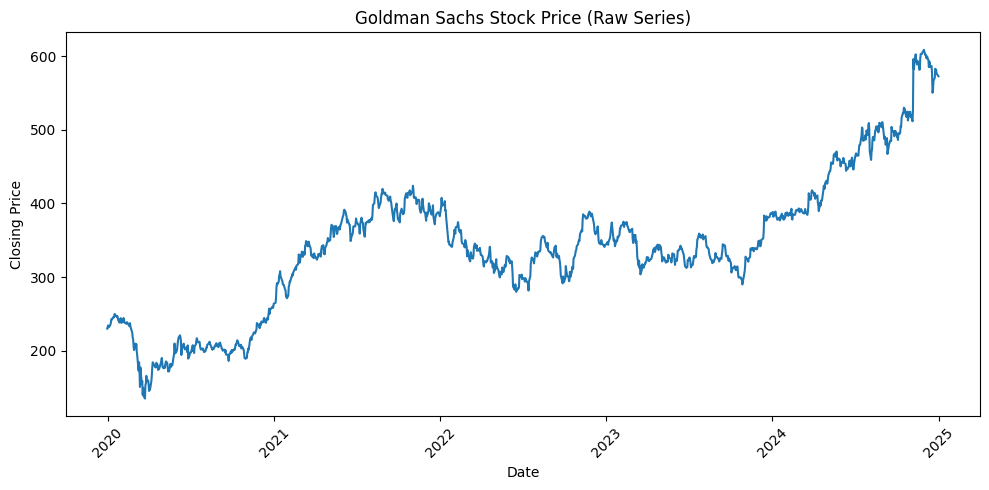

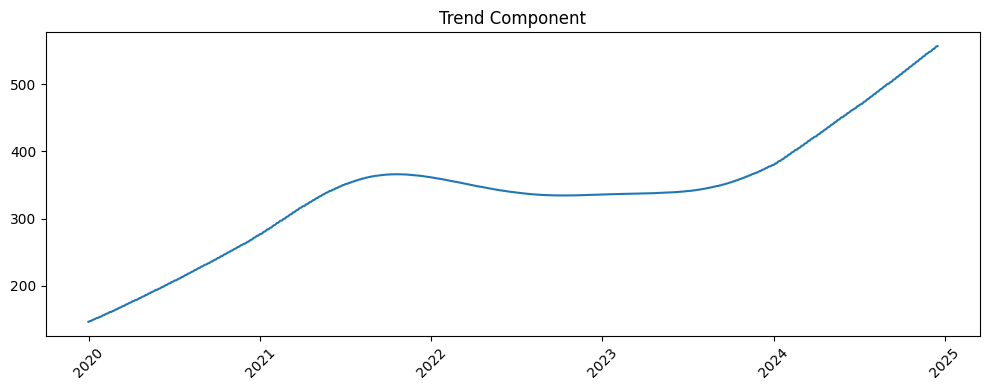

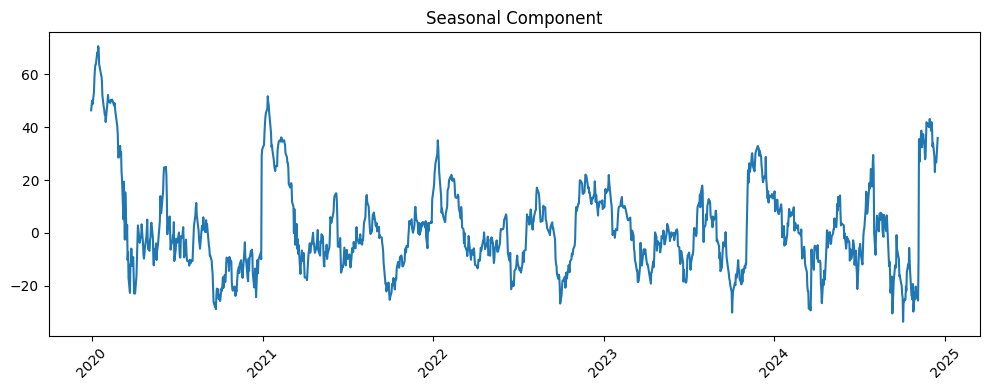

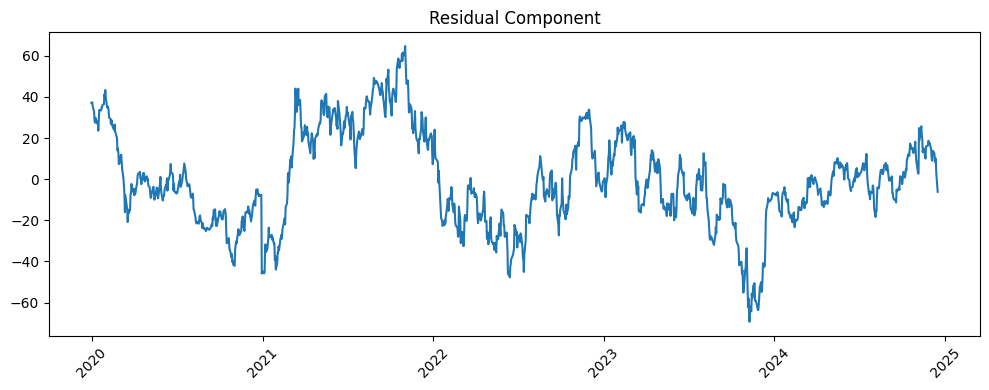

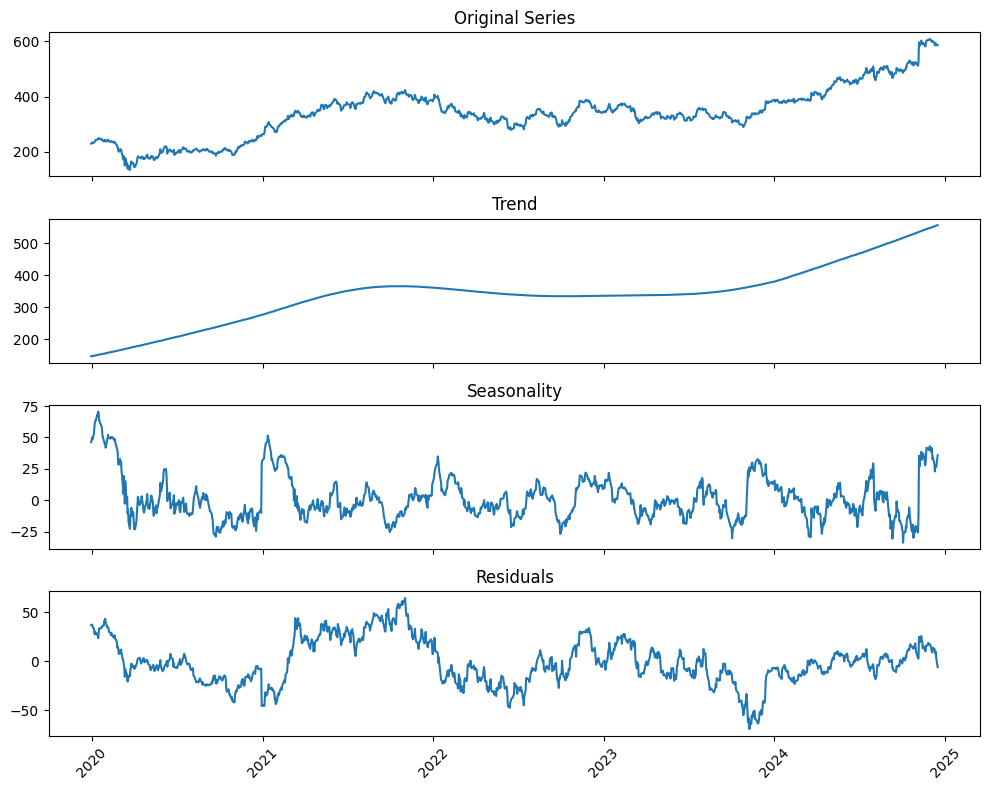

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from google.colab import files
uploaded = files.upload ()
import io
for fn in uploaded.keys():
  df = pd.read_csv(io.BytesIO(uploaded[fn]))
df.columns = df.iloc[1]
df = df[2:]
df = df.rename(columns={"Date": "Date", "Price": "Close"})
df = df[["Date", "Close"]]
df["Date"] = pd.to_datetime(df["Date"])
df["Close"] = pd.to_numeric(df["Close"], errors='coerce')
df = df.dropna()
df = df.sort_values("Date")
df = df.reset_index(drop=True)
print("Cleaned Data Shape:", df.shape)
print(df.head())
train = df.iloc[:-10]
test = df.iloc[-10:]

print("Train size:", train.shape)
print("Test size:", test.shape)
plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["Close"])
plt.title("Goldman Sachs Stock Price (Raw Series)")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
train_ts = train.set_index("Date")
stl = STL(train_ts["Close"], period=252)
result = stl.fit()
trend = result.trend
seasonal = result.seasonal
residual = result.resid
plt.figure(figsize=(10,4))
plt.plot(trend)
plt.title("Trend Component")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.figure(figsize=(10,4))
plt.plot(seasonal)
plt.title("Seasonal Component")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.figure(figsize=(10,4))
plt.plot(residual)
plt.title("Residual Component")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
fig, axes = plt.subplots(4, 1, figsize=(10,8), sharex=True)

axes[0].plot(train_ts["Close"])
axes[0].set_title("Original Series")

axes[1].plot(trend)
axes[1].set_title("Trend")

axes[2].plot(seasonal)
axes[2].set_title("Seasonality")

axes[3].plot(residual)
axes[3].set_title("Residuals")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


All libraries imported successfully.



Saving PriceHistory__5_.xlsx (2) (1).xlsx.xlsx to PriceHistory__5_.xlsx (2) (1).xlsx (1).xlsx
Header detected at row: 2
DATASET OVERVIEW
Total observations: 1259
Date range: 2019-12-31 → 2024-12-31
Price range: $134.97 — $608.57
Mean price: $342.00


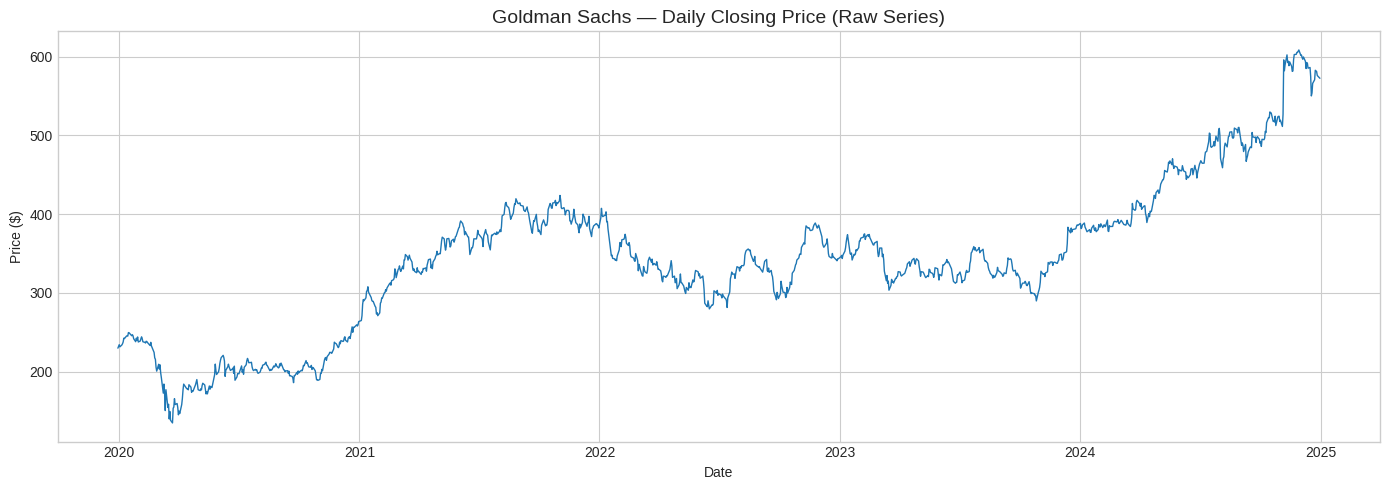



############################################################
# STEP 1 — STATIONARITY TESTING (Augmented Dickey-Fuller)
############################################################

📊 Testing RAW PRICE series...

  ADF Test: Raw Price
  Test Statistic:    -0.209191
  p-value:           0.937417
  Lags Used:         0
  Observations:      1258
  Critical Values:
    1%: -3.435559
    5%: -2.863840
    10%: -2.567995

  ❌ RESULT: NON-STATIONARY (p=0.937417 > 0.05)
     → Fail to reject H₀: The series HAS a unit root.

📊 Testing LOG-TRANSFORMED PRICE series...

  ADF Test: Log(Price)
  Test Statistic:    -0.795712
  p-value:           0.820378
  Lags Used:         8
  Observations:      1250
  Critical Values:
    1%: -3.435592
    5%: -2.863855
    10%: -2.568003

  ❌ RESULT: NON-STATIONARY (p=0.820378 > 0.05)
     → Fail to reject H₀: The series HAS a unit root.


############################################################
# STEP 2 — TRANSFORMATIONS TO ACHIEVE STATIONARITY
###########

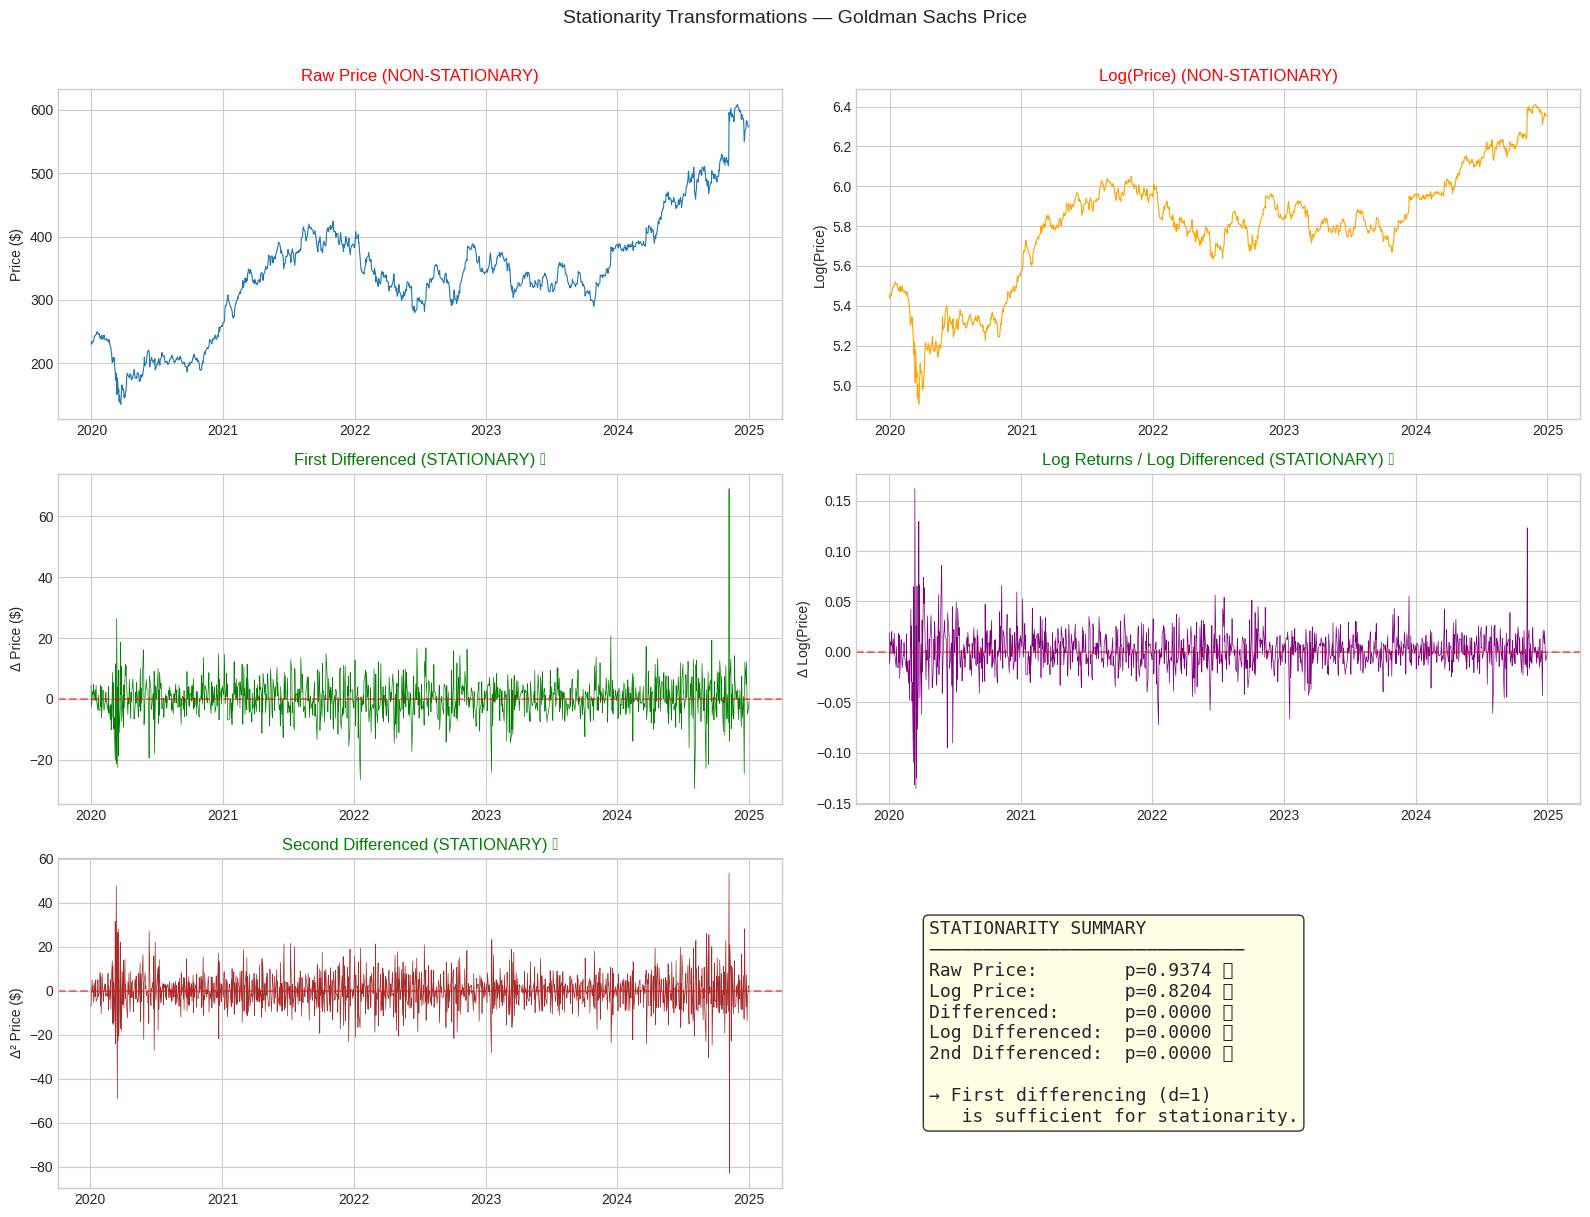



############################################################
# STEP 3 — ACF & PACF ANALYSIS
############################################################

Interpreting ACF and PACF to determine ARIMA(p, d, q):
  d = 1 (first differencing makes the series stationary)
  p = determined from PACF (number of significant lags)
  q = determined from ACF (number of significant lags)


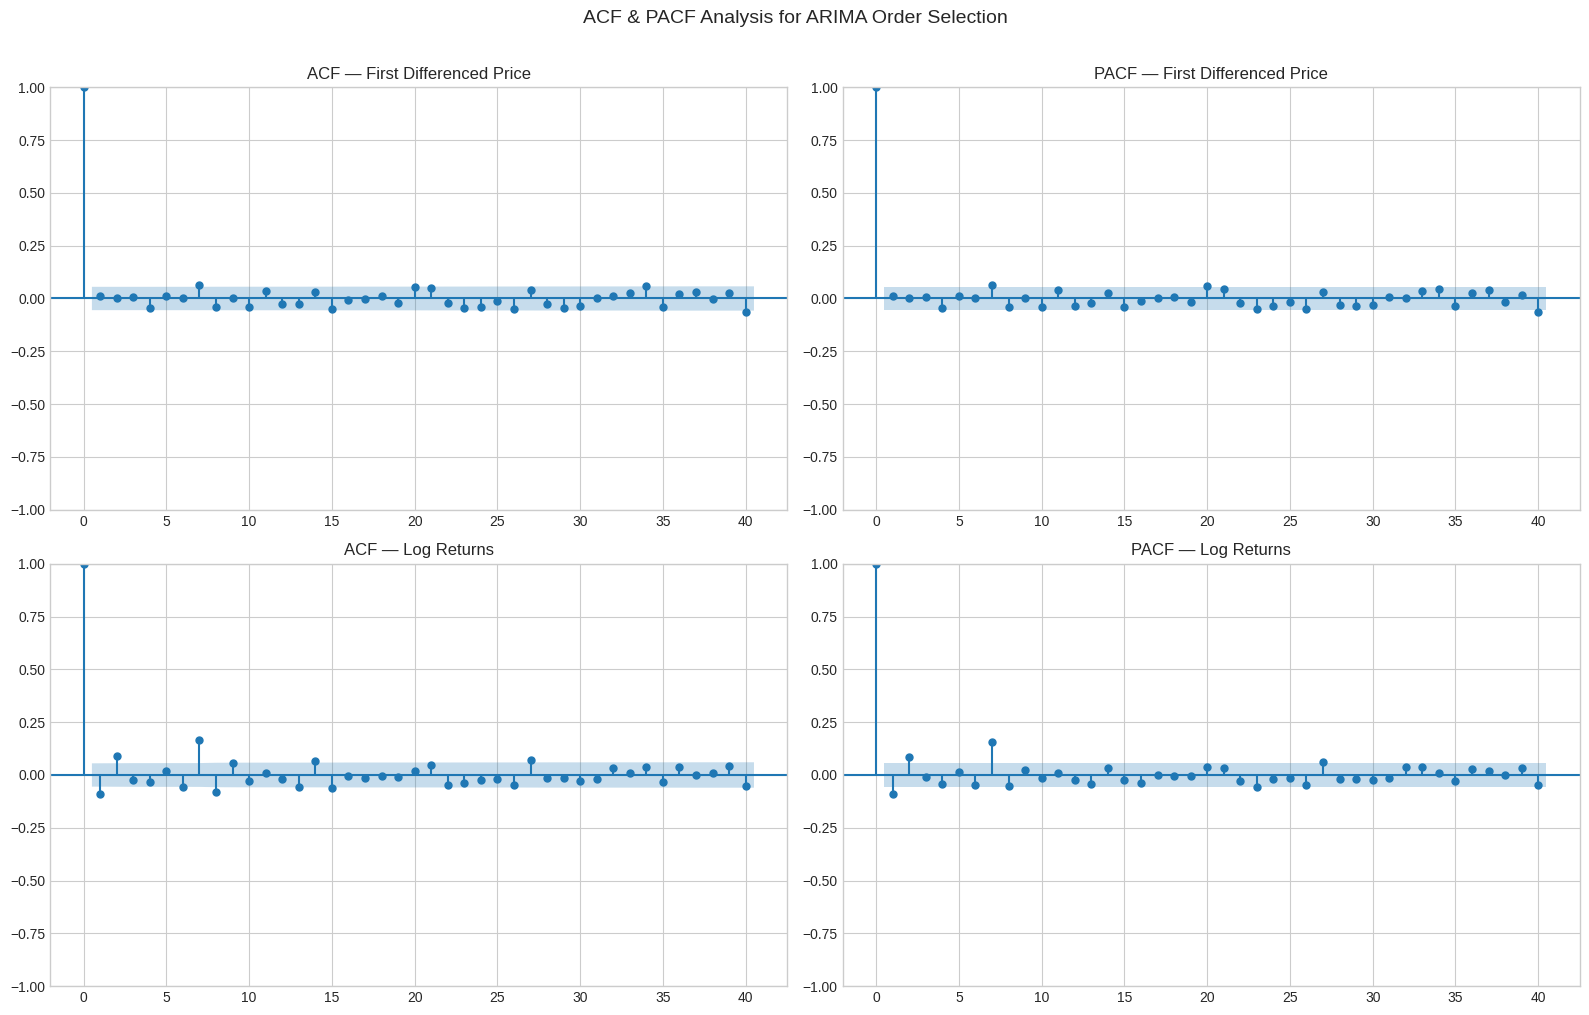


📊 ACF/PACF Interpretation:
──────────────────────────────────────────────────
• ACF shows how each observation correlates with past observations.
• PACF shows the DIRECT correlation after removing intermediate effects.
• Significant spike at lag k in PACF → suggests p = k
• Significant spike at lag k in ACF  → suggests q = k
• If ACF tails off & PACF cuts off after lag 1 → AR(1) model, p=1
• If ACF cuts off after lag 1 & PACF tails off → MA(1) model, q=1
• If both tail off → ARMA model needed, try combinations


############################################################
# STEP 4 — ARIMA MODEL FITTING (Manual Selection)
############################################################

Train: 1007 observations (2019-12-31 → 2023-12-29)
Test:  252 observations (2024-01-02 → 2024-12-31)

Model                         AIC          BIC   Log-Likelihood
──────────────────────────────────────────────────────────────
ARIMA(0, 1, 0)           6373.60      6378.51         -3185.80
ARIMA(1, 1, 0)  

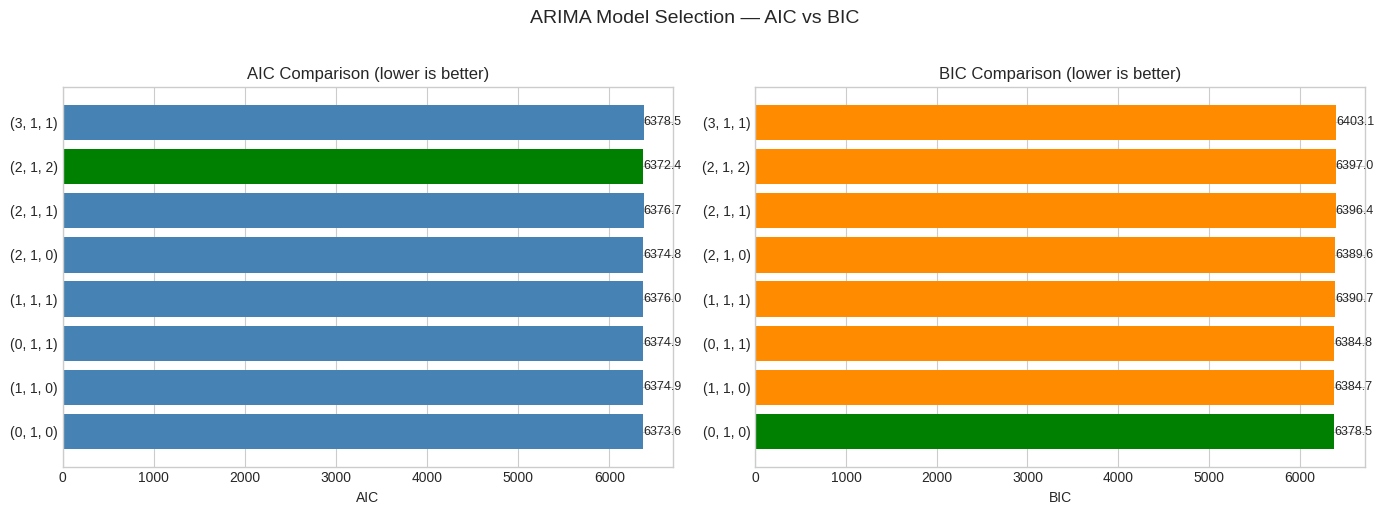



############################################################
# STEP 5 — AUTO ARIMA (pmdarima) VALIDATION
############################################################

Running auto_arima to find optimal order automatically...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=3.74 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=6374.867, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=6376.173, Time=0.13 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=6376.230, Time=0.24 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=6373.600, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=6377.347, Time=0.57 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 4.781 seconds

  AUTO ARIMA RESULT
  Best Order:  ARIMA(0, 1, 0)
  AIC:         6373.60
  BIC:         6378.51

Auto ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:  

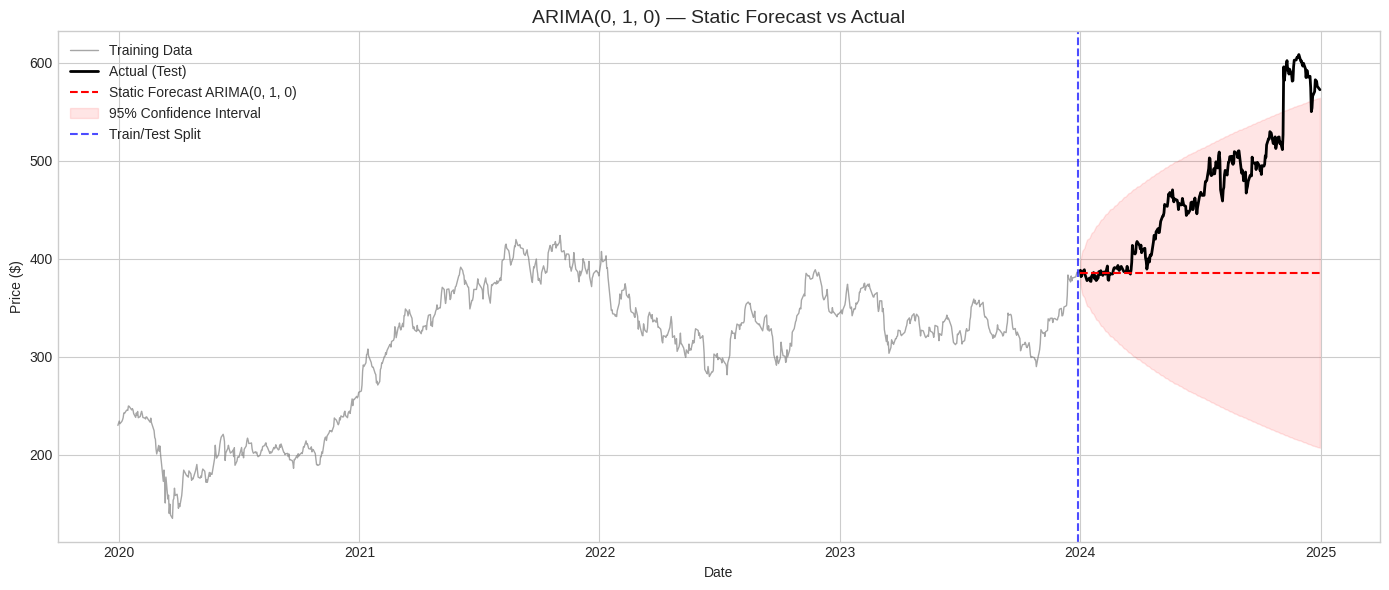


⚠️ Note: Static forecast predicts ALL future steps at once from the training data.
   For stock prices, this quickly diverges because each step compounds the error.
   Rolling (walk-forward) forecast below provides a more realistic evaluation.


############################################################
# STEP 7 — ROLLING (WALK-FORWARD) FORECAST
############################################################

Performing rolling 1-step-ahead forecast using ARIMA(0, 1, 0)...
(This re-fits the model at each step using all available history)
This may take 2-5 minutes...

  Completed 1/252 steps...
  Completed 50/252 steps...
  Completed 100/252 steps...
  Completed 150/252 steps...
  Completed 200/252 steps...
  Completed 250/252 steps...

  ROLLING FORECAST EVALUATION (1-step-ahead)
  MAE:     5.2062
  RMSE:    8.0174
  R²:      0.985709
  MAPE:    1.09%


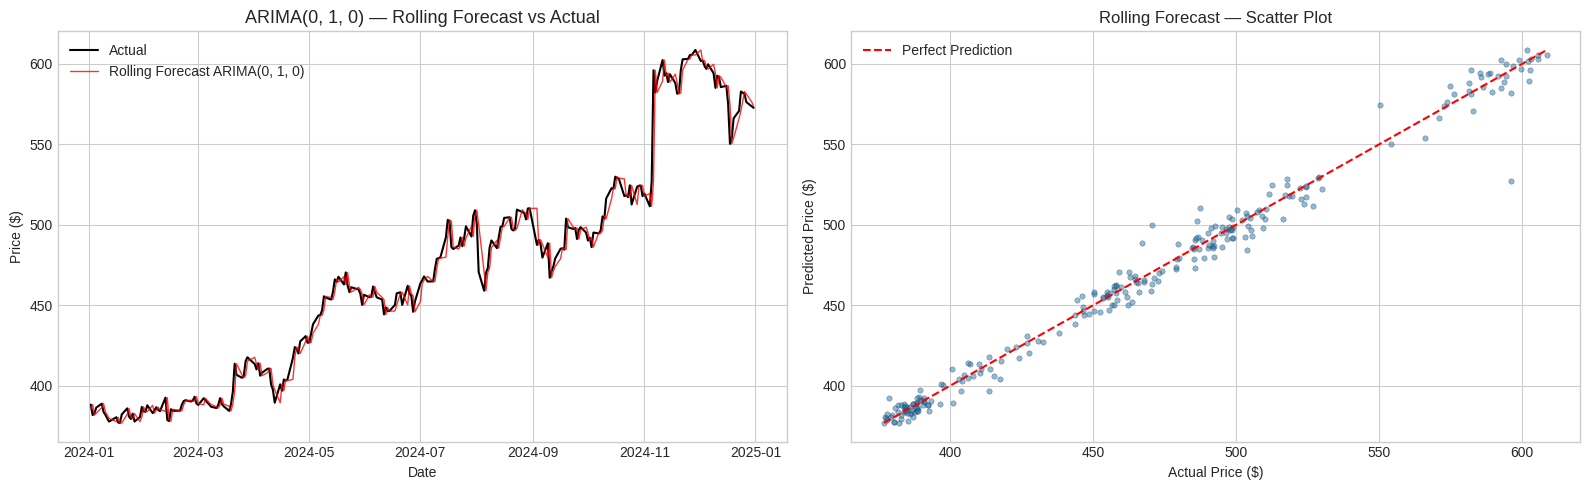



############################################################
# STEP 8 — RESIDUAL DIAGNOSTICS
############################################################


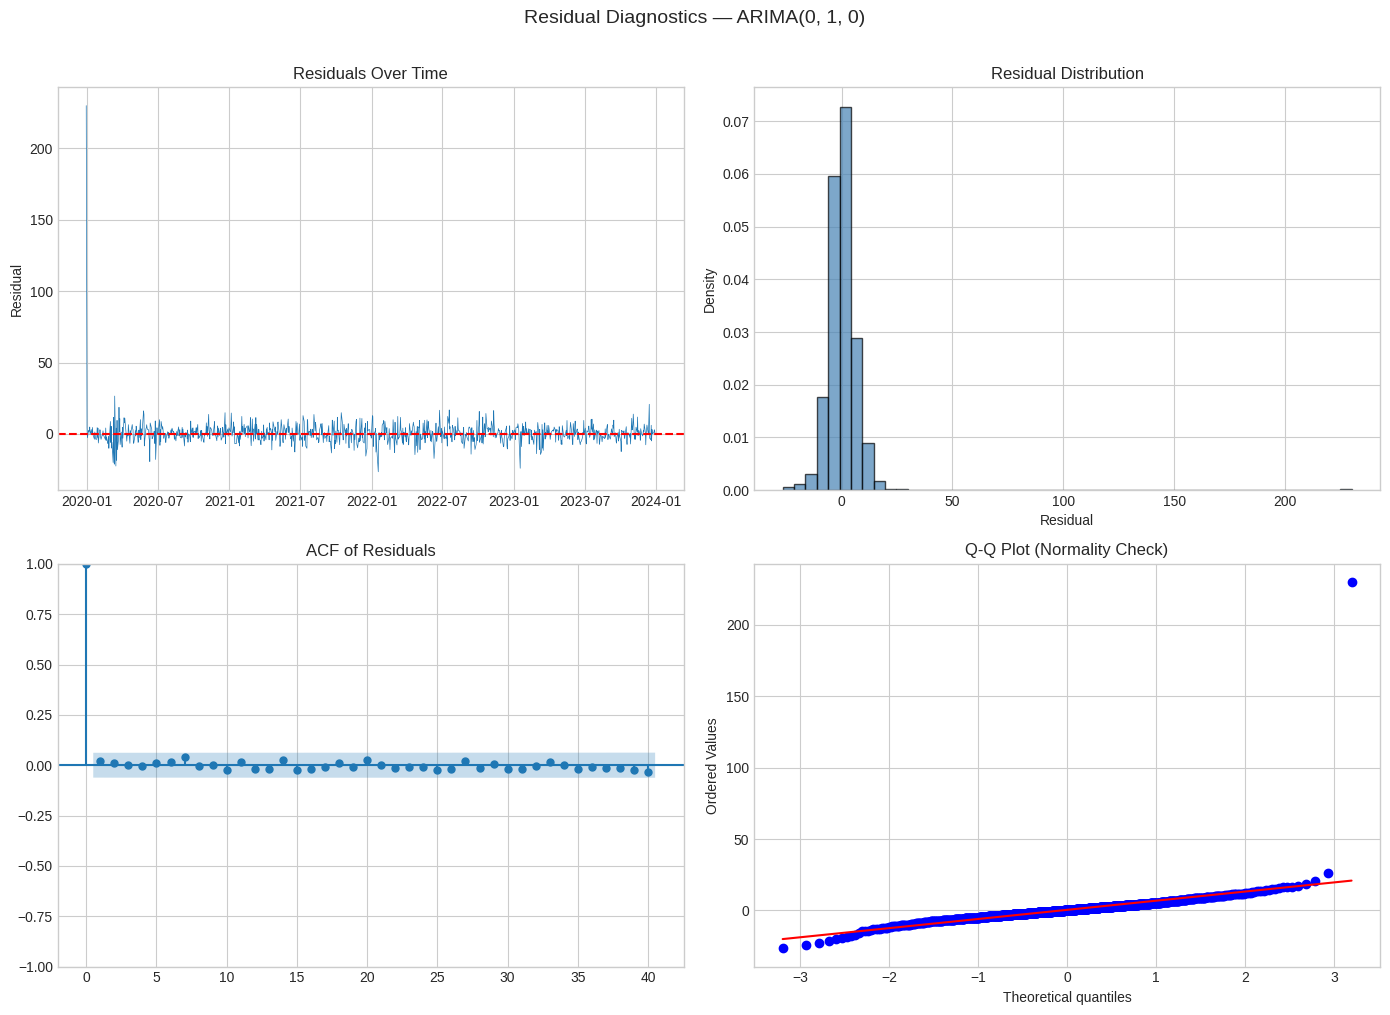


📊 Residual Analysis:
  Mean:      0.3831 (should be ≈ 0)
  Std Dev:   9.2401
  Skewness:  15.2098 (should be ≈ 0)
  Kurtosis:  378.5829 (should be ≈ 0 for normal)

  Ljung-Box Test (H₀: No autocorrelation in residuals):
     lb_stat  lb_pvalue
10  2.997366   0.981486
20  6.350494   0.998334
30  8.699739   0.999949

  ✅ No significant autocorrelation in residuals — model is adequate.


############################################################
# STEP 9 — FINAL COMPARISON
############################################################

   ARIMA(0, 1, 0) — STATIC vs ROLLING FORECAST COMPARISON
  Metric  Static Forecast  Rolling Forecast
     MAE        84.610913          5.206230
    RMSE       107.288780          8.017390
R² Score        -1.559249          0.985709
MAPE (%)              NaN          1.092475


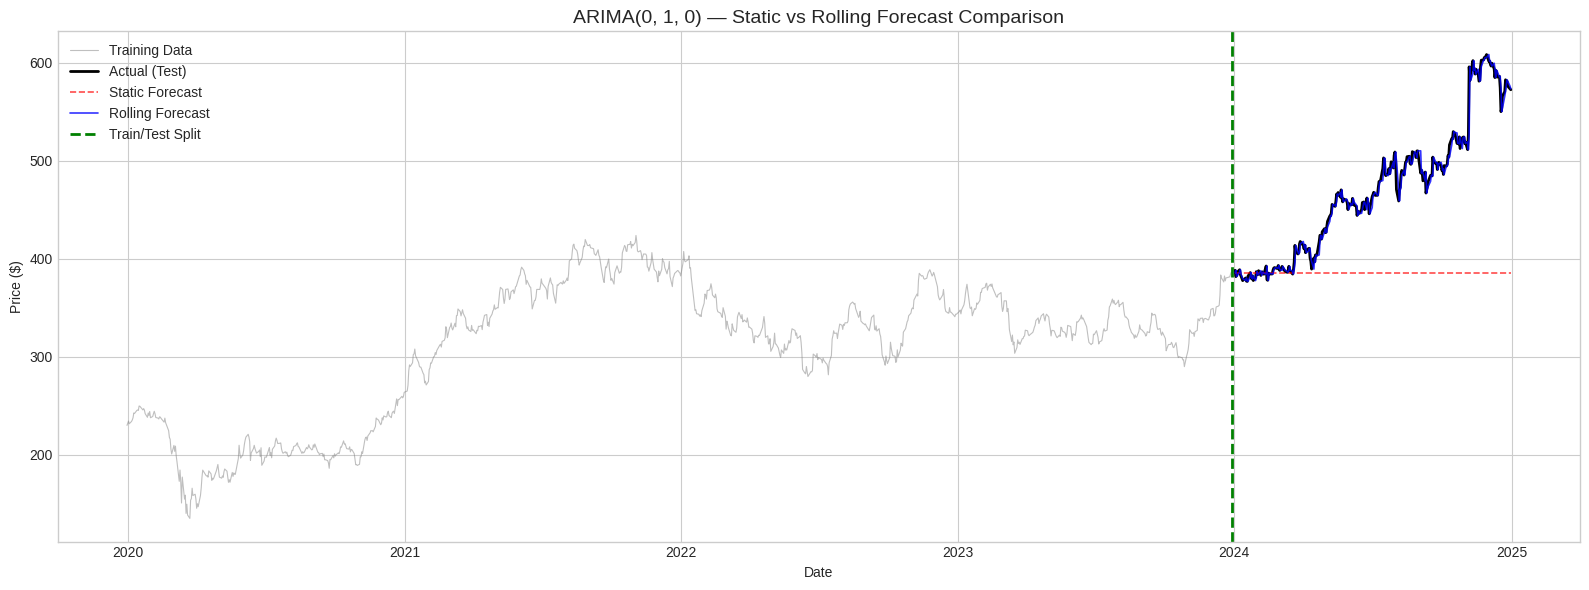


📊 Key Takeaway:
  • Static forecast diverges quickly — it predicts all steps from training data alone.
  • Rolling forecast updates with each new observation — much more accurate.
  • Rolling 1-step-ahead is the standard evaluation method for financial time series.
  • ARIMA captures short-term price momentum but cannot predict long-term trends.


✅ ARIMA ANALYSIS COMPLETE — NOTEBOOK FINISHED SUCCESSFULLY


In [ ]:
# --- 1. INSTALL & IMPORTS ---
!pip install pmdarima -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print("All libraries imported successfully.\n")

# --- 2. LOAD DATASET ---
from google.colab import files
uploaded = files.upload()

# Dynamically detect header row
df_raw = pd.read_excel('PriceHistory__5_.xlsx (2) (1).xlsx.xlsx', header=None)
header_row = None
for i in range(20):
    if 'Date' in df_raw.iloc[i].tolist():
        header_row = i
        break
print(f"Header detected at row: {header_row}")

df = pd.read_excel('PriceHistory__5_.xlsx (2) (1).xlsx.xlsx', header=header_row)
df = df.dropna(subset=['Price']).sort_values('Date').reset_index(drop=True)
df.set_index('Date', inplace=True)
price = df['Price']

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total observations: {len(price)}")
print(f"Date range: {price.index.min().date()} → {price.index.max().date()}")
print(f"Price range: ${price.min():.2f} — ${price.max():.2f}")
print(f"Mean price: ${price.mean():.2f}")

# Plot the raw price series
plt.figure(figsize=(14, 5))
plt.plot(price, linewidth=1)
plt.title('Goldman Sachs — Daily Closing Price (Raw Series)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

# ============================================================
# STEP 1 — TEST FOR STATIONARITY (ADF TEST)
# ============================================================
print("\n\n" + "#" * 60)
print("# STEP 1 — STATIONARITY TESTING (Augmented Dickey-Fuller)")
print("#" * 60)

def adf_test(series, name):
    """Perform ADF test and print results."""
    result = adfuller(series, autolag='AIC')
    print(f"\n{'='*60}")
    print(f"  ADF Test: {name}")
    print(f"{'='*60}")
    print(f"  Test Statistic:    {result[0]:.6f}")
    print(f"  p-value:           {result[1]:.6f}")
    print(f"  Lags Used:         {result[2]}")
    print(f"  Observations:      {result[3]}")
    print(f"  Critical Values:")
    for key, val in result[4].items():
        print(f"    {key}: {val:.6f}")
    if result[1] < 0.05:
        print(f"\n  ✅ RESULT: STATIONARY (p={result[1]:.6f} < 0.05)")
        print(f"     → Reject H₀: The series does NOT have a unit root.")
    else:
        print(f"\n  ❌ RESULT: NON-STATIONARY (p={result[1]:.6f} > 0.05)")
        print(f"     → Fail to reject H₀: The series HAS a unit root.")
    print(f"{'='*60}")
    return result

# Test 1: Raw Price
print("\n📊 Testing RAW PRICE series...")
adf_raw = adf_test(price, 'Raw Price')

# Test 2: Log Price
log_price = np.log(price)
print("\n📊 Testing LOG-TRANSFORMED PRICE series...")
adf_log = adf_test(log_price, 'Log(Price)')

# ============================================================
# STEP 2 — APPLY TRANSFORMATIONS TO ACHIEVE STATIONARITY
# ============================================================
print("\n\n" + "#" * 60)
print("# STEP 2 — TRANSFORMATIONS TO ACHIEVE STATIONARITY")
print("#" * 60)

# Transformation 1: First Differencing
diff_price = price.diff().dropna()
print("\n📊 Testing FIRST-DIFFERENCED PRICE series (d=1)...")
adf_diff = adf_test(diff_price, 'Differenced Price (Δ Price)')

# Transformation 2: Log + First Differencing (log returns)
log_diff = log_price.diff().dropna()
print("\n📊 Testing LOG-DIFFERENCED PRICE series (log returns)...")
adf_log_diff = adf_test(log_diff, 'Log Returns (Δ Log Price)')

# Transformation 3: Second Differencing (if needed)
diff2_price = price.diff().diff().dropna()
print("\n📊 Testing SECOND-DIFFERENCED PRICE series (d=2)...")
adf_diff2 = adf_test(diff2_price, 'Second Differenced Price (Δ² Price)')

# --- Visualise all transformations ---
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

axes[0, 0].plot(price, linewidth=0.8)
axes[0, 0].set_title('Raw Price (NON-STATIONARY)', fontsize=12, color='red')
axes[0, 0].set_ylabel('Price ($)')

axes[0, 1].plot(log_price, linewidth=0.8, color='orange')
axes[0, 1].set_title('Log(Price) (NON-STATIONARY)', fontsize=12, color='red')
axes[0, 1].set_ylabel('Log(Price)')

axes[1, 0].plot(diff_price, linewidth=0.5, color='green')
axes[1, 0].set_title('First Differenced (STATIONARY) ✅', fontsize=12, color='green')
axes[1, 0].set_ylabel('Δ Price ($)')
axes[1, 0].axhline(0, color='red', linestyle='--', alpha=0.5)

axes[1, 1].plot(log_diff, linewidth=0.5, color='purple')
axes[1, 1].set_title('Log Returns / Log Differenced (STATIONARY) ✅', fontsize=12, color='green')
axes[1, 1].set_ylabel('Δ Log(Price)')
axes[1, 1].axhline(0, color='red', linestyle='--', alpha=0.5)

axes[2, 0].plot(diff2_price, linewidth=0.5, color='brown')
axes[2, 0].set_title('Second Differenced (STATIONARY) ✅', fontsize=12, color='green')
axes[2, 0].set_ylabel('Δ² Price ($)')
axes[2, 0].axhline(0, color='red', linestyle='--', alpha=0.5)

axes[2, 1].axis('off')

# Summary table in empty subplot
summary_text = (
    "STATIONARITY SUMMARY\n"
    "─────────────────────────────\n"
    f"Raw Price:        p={adf_raw[1]:.4f} ❌\n"
    f"Log Price:        p={adf_log[1]:.4f} ❌\n"
    f"Differenced:      p={adf_diff[1]:.4f} ✅\n"
    f"Log Differenced:  p={adf_log_diff[1]:.4f} ✅\n"
    f"2nd Differenced:  p={adf_diff2[1]:.4f} ✅\n"
    "\n→ First differencing (d=1)\n   is sufficient for stationarity."
)
axes[2, 1].text(0.1, 0.5, summary_text, transform=axes[2, 1].transAxes,
                fontsize=13, verticalalignment='center', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Stationarity Transformations — Goldman Sachs Price', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ============================================================
# STEP 3 — ACF AND PACF PLOTS TO DETERMINE p, d, q
# ============================================================
print("\n\n" + "#" * 60)
print("# STEP 3 — ACF & PACF ANALYSIS")
print("#" * 60)

print("\nInterpreting ACF and PACF to determine ARIMA(p, d, q):")
print("  d = 1 (first differencing makes the series stationary)")
print("  p = determined from PACF (number of significant lags)")
print("  q = determined from ACF (number of significant lags)")

# ACF & PACF of the differenced series
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# First Differenced
plot_acf(diff_price, lags=40, ax=axes[0, 0], title='ACF — First Differenced Price')
plot_pacf(diff_price, lags=40, ax=axes[0, 1], title='PACF — First Differenced Price', method='ywm')

# Log Differenced (Log Returns)
plot_acf(log_diff, lags=40, ax=axes[1, 0], title='ACF — Log Returns')
plot_pacf(log_diff, lags=40, ax=axes[1, 1], title='PACF — Log Returns', method='ywm')

plt.suptitle('ACF & PACF Analysis for ARIMA Order Selection', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("\n📊 ACF/PACF Interpretation:")
print("─" * 50)
print("• ACF shows how each observation correlates with past observations.")
print("• PACF shows the DIRECT correlation after removing intermediate effects.")
print("• Significant spike at lag k in PACF → suggests p = k")
print("• Significant spike at lag k in ACF  → suggests q = k")
print("• If ACF tails off & PACF cuts off after lag 1 → AR(1) model, p=1")
print("• If ACF cuts off after lag 1 & PACF tails off → MA(1) model, q=1")
print("• If both tail off → ARMA model needed, try combinations")

# ============================================================
# STEP 4 — FIT ARIMA MODELS (MANUAL SELECTION)
# ============================================================
print("\n\n" + "#" * 60)
print("# STEP 4 — ARIMA MODEL FITTING (Manual Selection)")
print("#" * 60)

# Train/Test Split (80/20 chronological)
split_index = int(len(price) * 0.80)
train = price.iloc[:split_index]
test = price.iloc[split_index:]

print(f"\nTrain: {len(train)} observations ({train.index.min().date()} → {train.index.max().date()})")
print(f"Test:  {len(test)} observations ({test.index.min().date()} → {test.index.max().date()})")

# Try multiple ARIMA configurations
arima_orders = [
    (0, 1, 0),  # Random Walk
    (1, 1, 0),  # AR(1) with differencing
    (0, 1, 1),  # MA(1) with differencing
    (1, 1, 1),  # ARMA(1,1) with differencing
    (2, 1, 0),  # AR(2) with differencing
    (2, 1, 1),  # ARMA(2,1) with differencing
    (2, 1, 2),  # ARMA(2,2) with differencing
    (3, 1, 1),  # ARMA(3,1) with differencing
]

print(f"\n{'Model':<20} {'AIC':>12} {'BIC':>12} {'Log-Likelihood':>16}")
print("─" * 62)

arima_results = []
for order in arima_orders:
    try:
        model = ARIMA(train, order=order)
        fitted = model.fit()
        arima_results.append({
            'Order': order,
            'AIC': fitted.aic,
            'BIC': fitted.bic,
            'Log-Likelihood': fitted.llf
        })
        print(f"ARIMA{str(order):<14} {fitted.aic:>12.2f} {fitted.bic:>12.2f} {fitted.llf:>16.2f}")
    except Exception as e:
        print(f"ARIMA{str(order):<14} FAILED — {e}")

# Find best by AIC and BIC
results_df = pd.DataFrame(arima_results)
best_aic = results_df.loc[results_df['AIC'].idxmin()]
best_bic = results_df.loc[results_df['BIC'].idxmin()]

print(f"\n✅ Best model by AIC: ARIMA{best_aic['Order']} (AIC = {best_aic['AIC']:.2f})")
print(f"✅ Best model by BIC: ARIMA{best_bic['Order']} (BIC = {best_bic['BIC']:.2f})")

# Visual comparison of AIC/BIC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = [str(r['Order']) for r in arima_results]
aic_vals = [r['AIC'] for r in arima_results]
bic_vals = [r['BIC'] for r in arima_results]

colors_aic = ['green' if v == min(aic_vals) else 'steelblue' for v in aic_vals]
colors_bic = ['green' if v == min(bic_vals) else 'darkorange' for v in bic_vals]

axes[0].barh(labels, aic_vals, color=colors_aic)
axes[0].set_title('AIC Comparison (lower is better)', fontsize=12)
axes[0].set_xlabel('AIC')
for i, v in enumerate(aic_vals):
    axes[0].text(v + 0.5, i, f'{v:.1f}', va='center', fontsize=9)

axes[1].barh(labels, bic_vals, color=colors_bic)
axes[1].set_title('BIC Comparison (lower is better)', fontsize=12)
axes[1].set_xlabel('BIC')
for i, v in enumerate(bic_vals):
    axes[1].text(v + 0.5, i, f'{v:.1f}', va='center', fontsize=9)

plt.suptitle('ARIMA Model Selection — AIC vs BIC', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# STEP 5 — AUTO ARIMA (pmdarima) TO VALIDATE MANUAL SELECTION
# ============================================================
print("\n\n" + "#" * 60)
print("# STEP 5 — AUTO ARIMA (pmdarima) VALIDATION")
print("#" * 60)

print("\nRunning auto_arima to find optimal order automatically...")
auto_model = auto_arima(
    train,
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    max_p=5, max_q=5, max_d=2,
    information_criterion='aic',
    trace=True
)

print(f"\n{'='*60}")
print(f"  AUTO ARIMA RESULT")
print(f"{'='*60}")
print(f"  Best Order:  ARIMA{auto_model.order}")
print(f"  AIC:         {auto_model.aic():.2f}")
print(f"  BIC:         {auto_model.bic():.2f}")
print(f"{'='*60}")

print("\nAuto ARIMA Model Summary:")
print(auto_model.summary())

# ============================================================
# STEP 6 — FIT BEST MODEL & STATIC FORECAST
# ============================================================
print("\n\n" + "#" * 60)
print("# STEP 6 — BEST MODEL FITTING & FORECASTING")
print("#" * 60)

best_order = auto_model.order
print(f"\nFitting final model: ARIMA{best_order}")

final_model = ARIMA(train, order=best_order)
final_fitted = final_model.fit()

print("\nModel Summary:")
print(final_fitted.summary())

# Static forecast (full test set at once)
static_forecast = final_fitted.forecast(steps=len(test))
static_conf = final_fitted.get_forecast(steps=len(test)).conf_int()

# Evaluate static forecast
print(f"\n{'='*60}")
print(f"  STATIC FORECAST EVALUATION (Full test set at once)")
print(f"{'='*60}")
print(f"  MAE:     {mean_absolute_error(test, static_forecast):.4f}")
print(f"  RMSE:    {np.sqrt(mean_squared_error(test, static_forecast)):.4f}")
print(f"  R²:      {r2_score(test, static_forecast):.6f}")
print(f"  MAPE:    {np.mean(np.abs((test - static_forecast) / test)) * 100:.2f}%")
print(f"{'='*60}")

# Plot static forecast
plt.figure(figsize=(14, 6))
plt.plot(train.index, train.values, label='Training Data', linewidth=1, color='grey', alpha=0.7)
plt.plot(test.index, test.values, label='Actual (Test)', linewidth=2, color='black')
plt.plot(test.index, static_forecast.values, label=f'Static Forecast ARIMA{best_order}',
         linewidth=1.5, color='red', linestyle='--')
plt.fill_between(test.index, static_conf.iloc[:, 0], static_conf.iloc[:, 1],
                 color='red', alpha=0.1, label='95% Confidence Interval')
plt.axvline(x=train.index[-1], color='blue', linestyle='--', alpha=0.7, label='Train/Test Split')
plt.title(f'ARIMA{best_order} — Static Forecast vs Actual', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("\n⚠️ Note: Static forecast predicts ALL future steps at once from the training data.")
print("   For stock prices, this quickly diverges because each step compounds the error.")
print("   Rolling (walk-forward) forecast below provides a more realistic evaluation.\n")

# ============================================================
# STEP 7 — ROLLING (WALK-FORWARD) FORECAST
# ============================================================
print("\n" + "#" * 60)
print("# STEP 7 — ROLLING (WALK-FORWARD) FORECAST")
print("#" * 60)

print(f"\nPerforming rolling 1-step-ahead forecast using ARIMA{best_order}...")
print("(This re-fits the model at each step using all available history)")
print("This may take 2-5 minutes...\n")

rolling_predictions = []
history = list(train)

for t in range(len(test)):
    model = ARIMA(history, order=best_order)
    model_fit = model.fit()
    yhat = model_fit.forecast(steps=1)
    predicted_value = float(yhat.values[0]) if hasattr(yhat, 'values') else float(yhat[0])
    rolling_predictions.append(predicted_value)
    history.append(test.iloc[t])

    # Progress update
    if (t + 1) % 50 == 0 or t == 0:
        print(f"  Completed {t+1}/{len(test)} steps...")

rolling_preds = np.array(rolling_predictions)

print(f"\n{'='*60}")
print(f"  ROLLING FORECAST EVALUATION (1-step-ahead)")
print(f"{'='*60}")
print(f"  MAE:     {mean_absolute_error(test, rolling_preds):.4f}")
print(f"  RMSE:    {np.sqrt(mean_squared_error(test, rolling_preds)):.4f}")
print(f"  R²:      {r2_score(test, rolling_preds):.6f}")
print(f"  MAPE:    {np.mean(np.abs((test.values - rolling_preds) / test.values)) * 100:.2f}%")
print(f"{'='*60}")

# Plot rolling forecast
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Time series comparison
axes[0].plot(test.index, test.values, label='Actual', linewidth=1.5, color='black')
axes[0].plot(test.index, rolling_preds, label=f'Rolling Forecast ARIMA{best_order}',
             linewidth=1, color='red', alpha=0.8)
axes[0].set_title(f'ARIMA{best_order} — Rolling Forecast vs Actual', fontsize=13)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price ($)')
axes[0].legend()

# Scatter plot
axes[1].scatter(test.values, rolling_preds, alpha=0.5, s=15, edgecolors='k', linewidth=0.3)
min_val = min(test.min(), rolling_preds.min())
max_val = max(test.max(), rolling_preds.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')
axes[1].set_xlabel('Actual Price ($)')
axes[1].set_ylabel('Predicted Price ($)')
axes[1].set_title('Rolling Forecast — Scatter Plot')
axes[1].legend()

plt.tight_layout()
plt.show()

# ============================================================
# STEP 8 — RESIDUAL DIAGNOSTICS
# ============================================================
print("\n\n" + "#" * 60)
print("# STEP 8 — RESIDUAL DIAGNOSTICS")
print("#" * 60)

# Use the fitted model's residuals
residuals = final_fitted.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residual plot
axes[0, 0].plot(residuals, linewidth=0.5)
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('Residuals Over Time')
axes[0, 0].set_ylabel('Residual')

# Histogram
axes[0, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7, density=True, color='steelblue')
axes[0, 1].set_title('Residual Distribution')
axes[0, 1].set_xlabel('Residual')
axes[0, 1].set_ylabel('Density')

# ACF of residuals
plot_acf(residuals, lags=40, ax=axes[1, 0], title='ACF of Residuals')

# QQ plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normality Check)')

plt.suptitle(f'Residual Diagnostics — ARIMA{best_order}', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("\n📊 Residual Analysis:")
print(f"  Mean:      {residuals.mean():.4f} (should be ≈ 0)")
print(f"  Std Dev:   {residuals.std():.4f}")
print(f"  Skewness:  {residuals.skew():.4f} (should be ≈ 0)")
print(f"  Kurtosis:  {residuals.kurtosis():.4f} (should be ≈ 0 for normal)")

# Ljung-Box test for autocorrelation in residuals
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)
print(f"\n  Ljung-Box Test (H₀: No autocorrelation in residuals):")
print(lb_test.to_string())
if all(lb_test['lb_pvalue'] > 0.05):
    print("\n  ✅ No significant autocorrelation in residuals — model is adequate.")
else:
    print("\n  ⚠️ Some autocorrelation remains — model may need refinement.")

# ============================================================
# STEP 9 — COMPARISON: STATIC vs ROLLING FORECAST
# ============================================================
print("\n\n" + "#" * 60)
print("# STEP 9 — FINAL COMPARISON")
print("#" * 60)

comparison = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R² Score', 'MAPE (%)'],
    'Static Forecast': [
        mean_absolute_error(test, static_forecast),
        np.sqrt(mean_squared_error(test, static_forecast)),
        r2_score(test, static_forecast),
        np.mean(np.abs((test - static_forecast) / test)) * 100
    ],
    'Rolling Forecast': [
        mean_absolute_error(test, rolling_preds),
        np.sqrt(mean_squared_error(test, rolling_preds)),
        r2_score(test, rolling_preds),
        np.mean(np.abs((test.values - rolling_preds) / test.values)) * 100
    ]
})

print(f"\n{'='*70}")
print(f"   ARIMA{best_order} — STATIC vs ROLLING FORECAST COMPARISON")
print(f"{'='*70}")
print(comparison.to_string(index=False))
print(f"{'='*70}")

# Final overlay plot
plt.figure(figsize=(16, 6))
plt.plot(train.index, train.values, label='Training Data', linewidth=0.8, color='grey', alpha=0.5)
plt.plot(test.index, test.values, label='Actual (Test)', linewidth=2, color='black')
plt.plot(test.index, static_forecast.values, label='Static Forecast', linewidth=1.2,
         color='red', linestyle='--', alpha=0.7)
plt.plot(test.index, rolling_preds, label='Rolling Forecast', linewidth=1.2,
         color='blue', alpha=0.8)
plt.axvline(x=train.index[-1], color='green', linestyle='--', linewidth=2, label='Train/Test Split')
plt.title(f'ARIMA{best_order} — Static vs Rolling Forecast Comparison', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("\n📊 Key Takeaway:")
print("  • Static forecast diverges quickly — it predicts all steps from training data alone.")
print("  • Rolling forecast updates with each new observation — much more accurate.")
print("  • Rolling 1-step-ahead is the standard evaluation method for financial time series.")
print("  • ARIMA captures short-term price momentum but cannot predict long-term trends.")

print("\n\n" + "=" * 60)
print("✅ ARIMA ANALYSIS COMPLETE — NOTEBOOK FINISHED SUCCESSFULLY")
print("=" * 60)